# Notebook 06 — TimeSHAP on LSTM (CMAPSS FD001)

TimeSHAP keeps the (30, 15) sequence intact and attributes importance per timestep properly.

Reference: Bento et al., KDD 2021 — arxiv.org/abs/2012.00073

**Kernel:** Thesis (PyTorch)

In [9]:
import sys, pathlib

_venv_site = r'C:\venv\Lib\site-packages'
if _venv_site not in sys.path:
    sys.path.insert(0, _venv_site)
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import timeshap
import timeshap.explainer as tsx
import warnings
warnings.filterwarnings('ignore')

from src.data.cmapss_loader import CMAPSSLoader, SENSOR_PHYSICAL_NAMES, sensor_label
from src.data.preprocessor import TimeSeriesPreprocessor
from src.models.lstm_classifier import LSTMTrainer
from sklearn.metrics import classification_report

WINDOW     = 30
STEP       = 1
RUL_THRESH = 30

print('Imports OK')
print(f'torch={torch.__version__}  timeshap={timeshap.__version__}')

Imports OK
torch=2.13.0+cpu  timeshap=1.0.4


## 1 — Load & Preprocess

In [10]:
loader = CMAPSSLoader(data_dir='../data/raw/cmapss/CMaps')
train_df, test_df = loader.load('FD001')
train_df = loader.add_failure_label(train_df, RUL_THRESH)
test_df  = loader.add_failure_label(test_df,  RUL_THRESH)
train_df = loader.drop_constant_sensors(train_df)
test_df  = loader.drop_constant_sensors(test_df)

active_sensors = [c for c in train_df.columns if c.startswith('sensor')]
print(f'Active sensors: {len(active_sensors)}')

prep = TimeSeriesPreprocessor()
train_norm = prep.normalise(train_df, feature_cols=active_sensors)
test_norm  = prep.transform(test_df,  feature_cols=active_sensors)

def window_by_unit(df, feature_cols, label_col, window_size=30, step=1):
    X_list, y_list = [], []
    for uid, grp in df.groupby('unit_id'):
        grp = grp.sort_values('cycle')
        if len(grp) < window_size:
            continue
        X, y = TimeSeriesPreprocessor().create_windows(
            grp, feature_cols, label_col, window_size, step)
        X_list.append(X); y_list.append(y)
    return np.concatenate(X_list), np.concatenate(y_list)

X_train, y_train = window_by_unit(train_norm, active_sensors, 'failure_imminent', WINDOW, STEP)
X_test,  y_test  = window_by_unit(test_norm,  active_sensors, 'failure_imminent', WINDOW, STEP)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Active sensors: 15
Train: (17731, 30, 15)  |  Test: (10196, 30, 15)


## 2 — Train LSTM

In [11]:
lstm = LSTMTrainer(
    input_size=len(active_sensors), hidden_size=64, num_layers=2,
    num_classes=2, dropout=0.3, lr=1e-3, epochs=30, batch_size=256,
)
lstm.fit(X_train, y_train)
y_pred = lstm.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Failure']))

  Epoch 5/30  loss=0.0828
  Epoch 10/30  loss=0.0657
  Epoch 15/30  loss=0.0620
  Epoch 20/30  loss=0.0558
  Epoch 25/30  loss=0.0537
  Epoch 30/30  loss=0.0564
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      9864
     Failure       0.87      0.75      0.81       332

    accuracy                           0.99     10196
   macro avg       0.93      0.87      0.90     10196
weighted avg       0.99      0.99      0.99     10196



## 3 — Wrap LSTM for TimeSHAP

TimeSHAP needs: `f(X) -> P(failure)` where X is `(batch, timesteps, features)`.

In [12]:
def model_fn(X: np.ndarray) -> np.ndarray:
    proba = lstm.predict_proba(X)
    return proba[:, 1]   # P(failure)

sample = X_test[:5]
print('model_fn output shape:', model_fn(sample).shape)
print('P(failure) for 5 test samples:', np.round(model_fn(sample), 3))

model_fn output shape: (5,)
P(failure) for 5 test samples: [0. 0. 0. 0. 0.]


## 4 — Pruning Phase

TimeSHAP works backwards from the last timestep, finding the minimum
number of recent timesteps needed to explain the prediction.

In [20]:
failure_idx = np.where(y_test == 1)[0]
sample_to_explain = X_test[failure_idx[0]:failure_idx[0]+1]

print(f'Explaining sample index {failure_idx[0]}')
print(f'True label: Failure | P(failure): {model_fn(sample_to_explain)[0]:.4f}')

baseline = X_train.mean(axis=0, keepdims=True)

pruning_dict, pruned_idx = tsx.local_pruning(
    model_fn,
    sample_to_explain,
    {'tol': 0.025},
    baseline,
    entity_uuid=0,
    entity_col='entity',
    verbose=True,
)
print(f'\nPruned index (integer): {pruned_idx}')
print(f'→ LSTM needs last {WINDOW - pruned_idx} of {WINDOW} timesteps to explain this prediction')

Explaining sample index 1591
True label: Failure | P(failure): 0.1062
Allowed importance for pruned events: 0.025
len 0 | importance 0.1061302432208322
len -1 | importance 0.10270140195825661
len -2 | importance 0.07753809717360127
len -3 | importance 0.06046555046486901
len -4 | importance 0.05610219616210088
len -5 | importance 0.0540040435444098
len -6 | importance 0.051349348737858236
len -7 | importance 0.0506435775605496
len -8 | importance 0.04871971742250025
len -9 | importance 0.04725236566446256
len -10 | importance 0.04688775728573091
len -11 | importance 0.043943434495304246
len -12 | importance 0.04432076494413195
len -13 | importance 0.0438472099340288
len -14 | importance 0.043909952546528075
len -15 | importance 0.044069898925954476
len -16 | importance 0.042439463606569916
len -17 | importance 0.041689288926136214
len -18 | importance 0.03964118746807799
len -19 | importance 0.042165961873251945
len -20 | importance 0.042230586463119835
len -21 | importance 0.038364823

## 5 — Event-level Explanations

Importance per timestep — which of the 30 cycles mattered most.

In [21]:
event_data = tsx.local_event(
    model_fn,
    sample_to_explain,
    {'rs': 42, 'nsamples': 200},
    0,          # entity_uuid
    'entity',   # entity_col
    baseline,
    pruned_idx, # integer from local_pruning
)
print(event_data)

    Random seed  NSamples    Feature  Shapley Value
0            42       200   Event -1       0.000000
1            42       200   Event -2       0.004735
2            42       200   Event -3       0.001505
3            42       200   Event -4       0.006079
4            42       200   Event -5       0.004149
5            42       200   Event -6       0.001772
6            42       200   Event -7       0.001588
7            42       200   Event -8       0.000000
8            42       200   Event -9       0.001895
9            42       200  Event -10       0.000000
10           42       200  Event -11       0.005709
11           42       200  Event -12       0.000000
12           42       200  Event -13       0.003665
13           42       200  Event -14       0.002351
14           42       200  Event -15       0.000000
15           42       200  Event -16       0.000000
16           42       200  Event -17       0.000000
17           42       200  Event -18       0.000000
18          

## 6 — Feature-level Explanations

Importance per sensor — which of the 15 sensors mattered most.

In [23]:
feature_data = tsx.local_feat(
    model_fn,
    sample_to_explain,
    {'rs': 42, 'nsamples': 200},
    0,          # entity_uuid
    'entity',   # entity_col
    baseline,
    pruned_idx,
)

# Map feature index → sensor name
feat_col  = [c for c in feature_data.columns if 'feat' in c.lower()][0]
shap_col_f = [c for c in feature_data.columns if 'shap' in c.lower()][0]

feature_data['Sensor'] = feature_data[feat_col].apply(
    lambda x: active_sensors[int(x)] if str(x).lstrip('-').isdigit() else x
)
feature_data['Physical'] = feature_data['Sensor'].apply(
    lambda s: SENSOR_PHYSICAL_NAMES.get(s, s).split('—')[0].strip().split()[-1]
              if s in SENSOR_PHYSICAL_NAMES else s
)
print(feature_data[['Sensor', 'Physical', shap_col_f]].sort_values(shap_col_f, ascending=False))

        Sensor    Physical  Shapley Value
9    Feature 9   Feature 9       0.024102
13  Feature 13  Feature 13       0.020963
5    Feature 5   Feature 5       0.018712
8    Feature 8   Feature 8       0.015683
7    Feature 7   Feature 7       0.015455
11  Feature 11  Feature 11       0.013282
1    Feature 1   Feature 1       0.008662
3    Feature 3   Feature 3       0.005381
0    Feature 0   Feature 0       0.005372
12  Feature 12  Feature 12       0.003443
2    Feature 2   Feature 2       0.001623
4    Feature 4   Feature 4       0.000000
14  Feature 14  Feature 14       0.000000
10  Feature 10  Feature 10      -0.008136
6    Feature 6   Feature 6      -0.018412


## 7 — Plot Event Importance

Event data columns: ['Random seed', 'NSamples', 'Feature', 'Shapley Value']


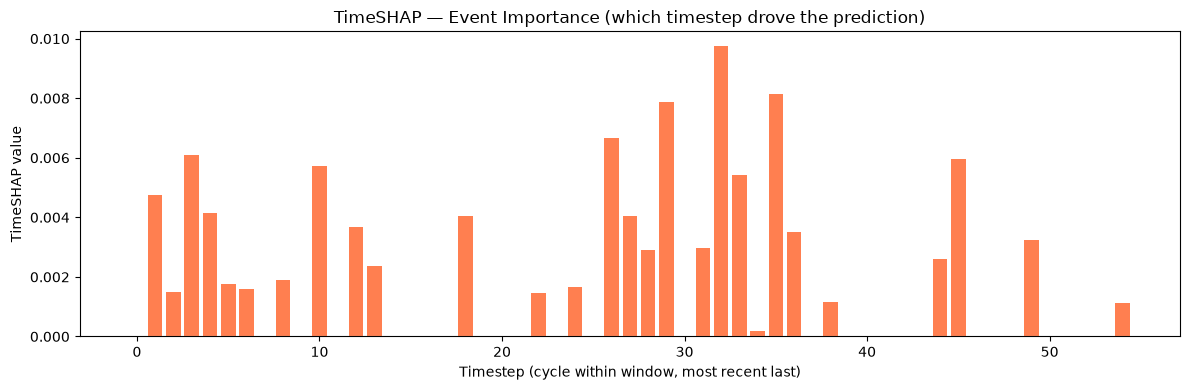

In [24]:
print('Event data columns:', event_data.columns.tolist())
shap_col = [c for c in event_data.columns if 'shap' in c.lower() or 'SHAP' in c][0]
time_col = [c for c in event_data.columns if 'time' in c.lower() or 'event' in c.lower() or 'Feat' in c][0]

fig, ax = plt.subplots(figsize=(12, 4))
vals = event_data[shap_col].values
ax.bar(range(len(vals)), vals, color=['coral' if v > 0 else 'steelblue' for v in vals])
ax.axhline(0, color='white', linewidth=0.8)
ax.set_xlabel('Timestep (cycle within window, most recent last)')
ax.set_ylabel('TimeSHAP value')
ax.set_title('TimeSHAP — Event Importance (which timestep drove the prediction)')
plt.tight_layout()
plt.savefig('../reports/figures/timeshap_event.png', dpi=150)
plt.show()

## 8 — Plot Feature Importance

Feature data columns: ['Random seed', 'NSamples', 'Feature', 'Shapley Value', 'Sensor', 'Physical']


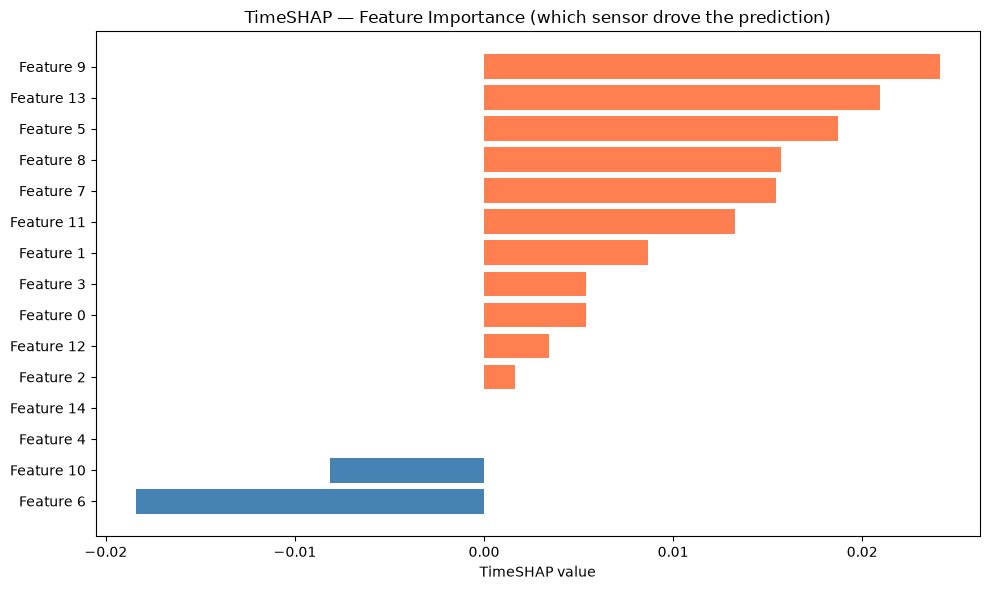

In [25]:
print('Feature data columns:', feature_data.columns.tolist())
shap_col_f = [c for c in feature_data.columns if 'shap' in c.lower() or 'SHAP' in c][0]
feat_col   = [c for c in feature_data.columns if 'feat' in c.lower() or 'name' in c.lower()][0]

fd_sorted = feature_data.sort_values(shap_col_f, ascending=True)
labels = [sensor_label(f) + f' ({f})' if f in SENSOR_PHYSICAL_NAMES else f
          for f in fd_sorted[feat_col]]

fig, ax = plt.subplots(figsize=(10, 6))
vals = fd_sorted[shap_col_f].values
ax.barh(range(len(vals)), vals, color=['coral' if v > 0 else 'steelblue' for v in vals])
ax.set_yticks(range(len(vals)))
ax.set_yticklabels(labels)
ax.set_xlabel('TimeSHAP value')
ax.set_title('TimeSHAP — Feature Importance (which sensor drove the prediction)')
plt.tight_layout()
plt.savefig('../reports/figures/timeshap_feature.png', dpi=150)
plt.show()

## 9 — KernelSHAP vs TimeSHAP Comparison

In [27]:
kernel_top5 = [
    ('sensor_13', 'NRf  — Corrected fan speed'),
    ('sensor_11', 'Ps30 — Static pressure HPC outlet'),
    ('sensor_12', 'phi  — Fuel flow / Ps30 ratio'),
    ('sensor_2',  'T24  — Temperature LPC outlet'),
    ('sensor_7',  'P30  — Total pressure HPC outlet'),
]

# Decode TimeSHAP feature indices → sensor names
feat_col   = [c for c in feature_data.columns if 'feat' in c.lower()][0]
shap_col_f = [c for c in feature_data.columns if 'shap' in c.lower()][0]

def decode_feat(x):
    try:
        idx = int(str(x).replace('Feature ', '').strip())
        return active_sensors[idx]
    except Exception:
        return str(x)

feature_data['Sensor']   = feature_data[feat_col].apply(decode_feat)
feature_data['Physical'] = feature_data['Sensor'].apply(
    lambda s: SENSOR_PHYSICAL_NAMES.get(s, s).split('—')[0].strip().split()[-1]
)

ts_top5 = feature_data.nlargest(5, shap_col_f)[['Sensor', 'Physical', shap_col_f]]

print('=== KernelSHAP top 5 ===')
for i, (s, name) in enumerate(kernel_top5, 1):
    phys = name.split('—')[0].strip().split()[-1]
    print(f'  #{i}  {s}  ({phys})')

print()
print('=== TimeSHAP top 5 ===')
for i, (_, row) in enumerate(ts_top5.iterrows(), 1):
    print(f'  #{i}  {row["Sensor"]}  ({row["Physical"]})  SHAP={row[shap_col_f]:.4f}')

print()
print('--- Overlap ---')
k_set = {s for s, _ in kernel_top5}
t_set = set(ts_top5['Sensor'])
print(f'  Both agree on: {k_set & t_set}')
print(f'  Only KernelSHAP: {k_set - t_set}')
print(f'  Only TimeSHAP:   {t_set - k_set}')

=== KernelSHAP top 5 ===
  #1  sensor_13  (NRf)
  #2  sensor_11  (Ps30)
  #3  sensor_12  (phi)
  #4  sensor_2  (T24)
  #5  sensor_7  (P30)

=== TimeSHAP top 5 ===
  #1  sensor_13  (NRf)  SHAP=0.0241
  #2  sensor_20  (W31)  SHAP=0.0210
  #3  sensor_8  (Nf)  SHAP=0.0187
  #4  sensor_12  (phi)  SHAP=0.0157
  #5  sensor_11  (Ps30)  SHAP=0.0155

--- Overlap ---
  Both agree on: {'sensor_11', 'sensor_13', 'sensor_12'}
  Only KernelSHAP: {'sensor_7', 'sensor_2'}
  Only TimeSHAP:   {'sensor_20', 'sensor_8'}
